In [1]:
from dlfs.layers import EmbeddingLayer, PositionalEncoding, DenseLayer
from dlfs.modules import TransformerDecoder

from dlfs.activation import Softmax, ReLU, GELU, Sigmoid
from dlfs.loss import CCE_Loss, BCE_Loss, MSE_Loss
from dlfs.optimizers import Optimizer_Adam

from dlfs.base import Module

import numpy as np

In [2]:
import numpy as np

def generate_gpt_dataset(num_samples=1000, seq_len=5, vocab_size=20, sos_token=0):
    # Random sequences
    X_raw = np.random.randint(1, vocab_size, size=(num_samples, seq_len))

    # Decoder input: prepend SOS, remove last element
    X = np.zeros_like(X_raw)
    X[:, 1:] = X_raw[:, :-1]
    X[:, 0] = sos_token

    # Target is the original sequence
    y = X_raw.copy()

    return X, y

def get_random_batch(X, y, batch_size):
    idx = np.random.randint(0, len(X), size=(batch_size, ))
    return X[idx], y[idx]


In [3]:
class TransformerDecoderModel(Module):

    def __init__(self, vocab_size=12, block_size=5, 
                       n_embed=512, n_head = 4, n_dec_layers=2, dim_ff=2048,
                       dropout=0.1, activation=ReLU(), layer_norm_eps=1e-5, loss_function=None, optimizer=None):
        
        self.loss_function = loss_function
        self.optimizer = optimizer

        self.embed = EmbeddingLayer(vocab_size, n_embed)
        self.pos_enc = PositionalEncoding(block_size, n_embed)

        self.decoder = TransformerDecoder(d_model=n_embed, n_head=n_head, n_dec_layers=n_dec_layers,
                                          dim_ff=dim_ff, dropout=dropout, activation=activation, layer_norm_eps=layer_norm_eps)

        self.linear = DenseLayer(n_embed, vocab_size)
        self.softm = Softmax()

    def forward(self, inputs, training):

        self.embed.forward(inputs, training)

        self.pos_enc.forward(self.embed.output, training)

        self.decoder.forward(self.pos_enc.output, training)

        self.linear.forward(self.decoder.output, training)

        self.softm.forward(self.linear.output, training)

        self.output = self.softm.output

    def backward(self, output, y):

        B, T, C = output.shape
        output = output.reshape(B*T, C)
        y = y.reshape(B*T, )

        #print(f'output: {output.shape}, y: {y.shape}')

        # Compute loss gradient
        self.loss_function.backward(output, y)
        
        # Backprop through softmax + linear
        self.softm.backward(self.loss_function.dinputs)
        self.linear.backward(self.softm.dinputs)

        # Backprop through decoder, positional encoding, and embedding
        self.decoder.backward(self.linear.dinputs)
        self.pos_enc.backward(self.decoder.dinputs)
        self.embed.backward(self.pos_enc.dinputs)


    def train(self, X, y, epochs = 1000, batch_size: int = None, print_every: int = None):

        self.loss_vals = []

        for i in range(epochs + 1):

            if batch_size is not None:

                batch_X, batch_y = get_random_batch(X, y, batch_size=batch_size)

                self.forward(batch_X, training=True)
                self.backward(self.output, batch_y)

                self.optimizer.pre_update_parameters()
                self.optimizer.update_parameters(self)
                self.optimizer.post_update_parameters()

                B, T, C = self.output.shape
                output = self.output.reshape(B*T, C)
                y_reshape = batch_y.reshape(B*T, )

                loss = self.loss_function.calculate(output, y_reshape)
                self.loss_vals.append(loss)

                if print_every is not None and not i % print_every:
                    print(f'===== EPOCH : {i} ===== LOSS : {loss} =====')
                
            else:
                self.forward(X, training=True)
                self.backward(self.output, y)

                self.optimizer.pre_update_parameters()
                self.optimizer.update_parameters(self)
                self.optimizer.post_update_parameters()

                B, T, C = self.output.shape
                output = self.output.reshape(B*T, C)
                y_reshape = y.reshape(B*T, )

                loss = self.loss_function.calculate(output, y_reshape)
                self.loss_vals.append(loss)

                if print_every is not None and not i % print_every:
                    print(f'===== EPOCH : {i} ===== LOSS : {loss} =====')
                
    def predict(self, X):
        self.forward(X)
        return self.output > 0.5

In [ ]:
X_train, y_train = generate_gpt_dataset(num_samples=100)
#y_train = y_train.reshape(*y_train.shape, 1)
              
print(X_train.shape)
print(y_train.shape)

print(X_train[:2])
print(y_train[:2])

(10, 5)
(10, 5)
[[ 0  7 17 11 16]
 [ 0  6  1 14 18]]
[[ 7 17 11 16 16]
 [ 6  1 14 18  5]]


In [5]:
#np.random.seed(1)

vocab_size = max(max(X_train.flatten()), max(y_train.flatten())) + 1
block_size = X_train.shape[-1]
batch_size = None

n_embed = 64
n_head = 8
n_dec_layers = 1
dim_ff = 128
dropout = 0.
eps = 1e-5

epochs = 100
lr = 1e-4

loss = CCE_Loss(from_logits=False)
optimizer = Optimizer_Adam(learning_rate=lr, decay=0., clip_grad=False)

model = TransformerDecoderModel(vocab_size=vocab_size, 
                         block_size=block_size, 
                         n_embed=n_embed, 
                         n_head=n_head,
                         n_dec_layers=n_dec_layers,
                         dim_ff=dim_ff, 
                         dropout=dropout,
                         layer_norm_eps=eps,
                         loss_function=loss, 
                         optimizer=optimizer)

model.train(X_train, y_train, print_every=50, epochs=epochs, batch_size=batch_size)

===== EPOCH : 0 ===== LOSS : 6.327396844857525 =====
===== EPOCH : 50 ===== LOSS : 2.7919365221366035 =====
===== EPOCH : 100 ===== LOSS : 2.3594742405370392 =====


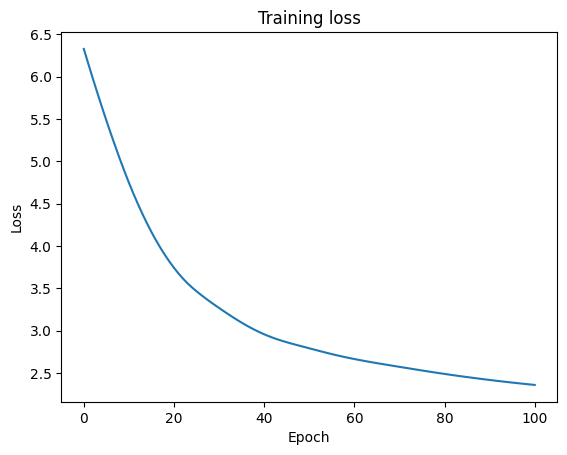

In [6]:
import matplotlib.pyplot as plt

plt.plot(range(len(model.loss_vals)), model.loss_vals)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [7]:
def generate(idx, max_new_tokens):
        
        for _ in range(max_new_tokens):

            idx_cond = idx[:, -block_size:]

            model.forward(idx, training=False)
    
            logits = model.output

            probs = logits[:, -1, :].reshape(-1)

            #print(probs)

            idx_next = np.argmax(np.random.multinomial(n=1, pvals=probs, size=1), axis=1).reshape(1, 1)

            idx = np.concatenate((idx, idx_next), axis=1)

        return idx

In [8]:
print(generate(idx=np.zeros((1, 1), dtype=np.int16), max_new_tokens=10)[0].tolist())

[0, 13, 11, 10, 1, 8, 14, 9, 9, 8, 7]
